# 03 - Exploratory Data Analysis

Notebook nay dung de phan tich du lieu da lam sach.

Muc tieu:

- Xem phan bo `Rating`
- Xem phan bo `sentiment`
- Phan tich do dai review
- Xem vi du review theo tung sentiment
- Luu bieu do vao thu muc `figures/`

## Buoc 1 - Import thu vien

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

## Buoc 2 - Khai bao duong dan

In [2]:
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

CLEAN_DATA_PATH = PROJECT_ROOT / "data" / "processed" / "clean_reviews.csv"
FIGURES_DIR = PROJECT_ROOT / "figures"

print("Clean data path:", CLEAN_DATA_PATH)
print("Figures dir:", FIGURES_DIR)
print("Clean file exists:", CLEAN_DATA_PATH.exists())

Clean data path: c:\Users\ADMIN\Downloads\Documents\DS\Project\data\processed\clean_reviews.csv
Figures dir: c:\Users\ADMIN\Downloads\Documents\DS\Project\figures
Clean file exists: True


## Buoc 3 - Doc du lieu da lam sach

In [3]:
df = pd.read_csv(CLEAN_DATA_PATH)
df["review_clean"] = df["review_clean"].fillna("")

print("So dong:", df.shape[0])
print("So cot:", df.shape[1])

So dong: 9219
So cot: 4


## Buoc 4 - Kiem tra nhanh du lieu

In [4]:
df.head()

,Review,Rating,review_clean,sentiment
0,"The ambience was good, food was quite good . h...",5,the ambience was good food was quite good had ...,Positive
1,Ambience is too good for a pleasant evening. S...,5,ambience is too good for a pleasant evening se...,Positive
2,A must try.. great food great ambience. Thnx f...,5,a must try great food great ambience thnx for ...,Positive
3,Soumen das and Arun was a great guy. Only beca...,5,soumen das and arun was a great guy only becau...,Positive
4,Food is good.we ordered Kodi drumsticks and ba...,5,food is good we ordered kodi drumsticks and ba...,Positive


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9219 entries, 0 to 9218
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Review        9219 non-null   object
 1   Rating        9219 non-null   int64 
 2   review_clean  9219 non-null   object
 3   sentiment     9219 non-null   object
dtypes: int64(1), object(3)
memory usage: 288.2+ KB


## Buoc 5 - Phan bo Rating

In [6]:
rating_counts = df["Rating"].value_counts().sort_index()

rating_counts

Rating
1    1710
2     675
3    1163
4    2297
5    3374
Name: count, dtype: int64

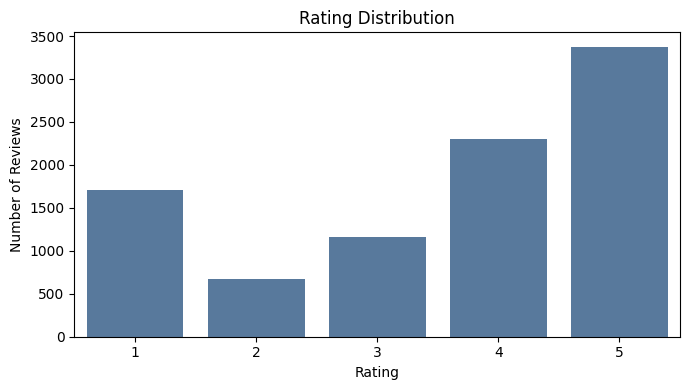

In [7]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x="Rating", color="#4C78A8")
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")
plt.tight_layout()
plt.show()

## Buoc 6 - Phan bo Sentiment

In [8]:
sentiment_order = ["Negative", "Neutral", "Positive"]
sentiment_counts = df["sentiment"].value_counts().reindex(sentiment_order)

sentiment_counts

sentiment
Negative    2385
Neutral     1163
Positive    5671
Name: count, dtype: int64

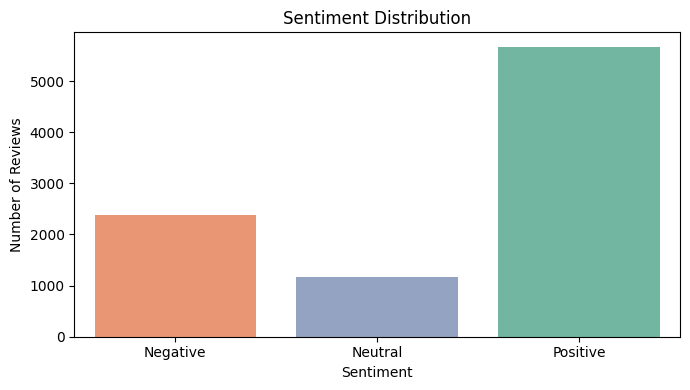

In [9]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x="sentiment", order=sentiment_order, palette="Set2", hue="sentiment", legend=False)
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.tight_layout()
plt.show()

## Buoc 7 - Tao cot do dai review

`review_length` la so tu trong `review_clean`.

In [10]:
df["review_length"] = df["review_clean"].str.split().str.len()

df[["review_clean", "review_length"]].head()

,review_clean,review_length
0,the ambience was good food was quite good had ...,38
1,ambience is too good for a pleasant evening se...,26
2,a must try great food great ambience thnx for ...,30
3,soumen das and arun was a great guy only becau...,28
4,food is good we ordered kodi drumsticks and ba...,28


## Buoc 8 - Thong ke do dai review

In [11]:
df["review_length"].describe()

count    9219.000000
mean       52.755396
std        60.873458
min         0.000000
25%        26.000000
50%        36.000000
75%        60.000000
max       969.000000
Name: review_length, dtype: float64

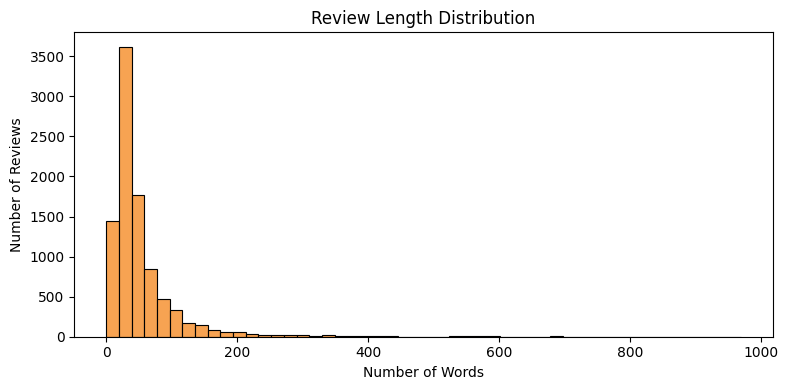

In [12]:
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x="review_length", bins=50, color="#F58518")
plt.title("Review Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Number of Reviews")
plt.tight_layout()
plt.show()

## Buoc 9 - Do dai review theo Sentiment

In [13]:
df.groupby("sentiment")["review_length"].describe().reindex(sentiment_order)

,count,mean,std,min,25%,50%,75%,max
sentiment,,,,,,,,
Negative,2385.0,49.019287,53.904803,0.0,23.0,35.0,58.0,617.0
Neutral,1163.0,58.024076,59.433277,0.0,28.0,41.0,71.0,695.0
Positive,5671.0,53.246165,63.772181,0.0,27.0,35.0,59.0,969.0


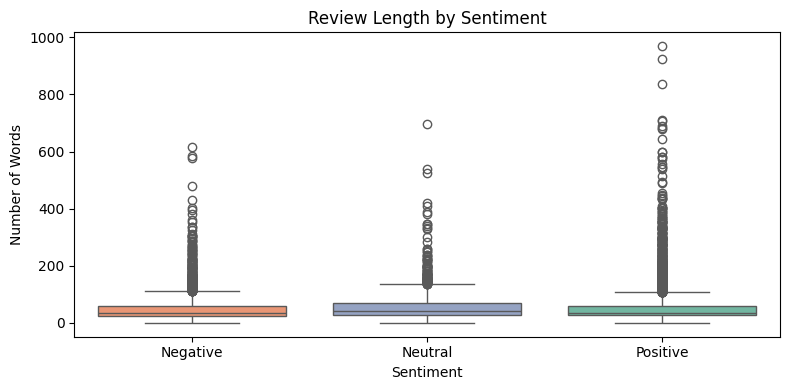

In [14]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x="sentiment", y="review_length", order=sentiment_order, palette="Set2", hue="sentiment", legend=False)
plt.title("Review Length by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Number of Words")
plt.tight_layout()
plt.show()

## Buoc 10 - Xem vi du review theo Sentiment

In [15]:
for sentiment in sentiment_order:
    print("=" * 80)
    print(sentiment)
    examples = df[df["sentiment"] == sentiment][["Rating", "Review"]].head(3)
    display(examples)

Negative


,Rating,Review
14,1,"We ordered corn cheese balls, manchow soup and..."
66,1,"we went for a team lunch, such a worst restaur..."
75,2,I have been at this place for dinner a few day...


Neutral


,Rating,Review
30,3,"Short review: Decent breads and starters, bad ..."
45,3,The reason for giving only a 3 star is because...
56,3,We went for lunch buffet yesterday and took a ...


Positive


,Rating,Review
0,5,"The ambience was good, food was quite good . h..."
1,5,Ambience is too good for a pleasant evening. S...
2,5,A must try.. great food great ambience. Thnx f...


## Buoc 11 - Luu bieu do vao figures

In [16]:
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(7, 4))
sns.countplot(data=df, x="Rating", color="#4C78A8")
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "rating_distribution.png", dpi=150)
plt.close()

plt.figure(figsize=(7, 4))
sns.countplot(data=df, x="sentiment", order=sentiment_order, palette="Set2", hue="sentiment", legend=False)
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "sentiment_distribution.png", dpi=150)
plt.close()

plt.figure(figsize=(8, 4))
sns.histplot(data=df, x="review_length", bins=50, color="#F58518")
plt.title("Review Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Number of Reviews")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "review_length_distribution.png", dpi=150)
plt.close()

print("Da luu bieu do vao:", FIGURES_DIR)

Da luu bieu do vao: c:\Users\ADMIN\Downloads\Documents\DS\Project\figures


## Ket luan nhanh

Sau EDA, ta can ghi nhan:

- Lop `Positive` nhieu hon `Negative` va `Neutral`
- Du lieu co the bi lech lop, nen khi train model khong chi nhin accuracy
- Can xem them F1-score va confusion matrix o notebook train model